# A — Data acquisition and processing

This notebook downloads the four raw datasets used in the analysis, clips them to the corridor bounding box (12°E–30°E, 16°S–5°S), and aggregates everything to a shared H3 resolution-7 hex grid (~5.93 km² per cell). The output is `data/processed/hex_features.gpkg`, which notebooks B and C read directly.

In [1]:
import re
import warnings
from pathlib import Path

import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import pooch
from shapely.geometry import Polygon, box
from shapely.ops import unary_union

warnings.filterwarnings("ignore")

/Users/inge/Desktop/ITU/GeoDS/gds/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "submission" else Path.cwd()
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR  = PROJECT_ROOT / "figures"
for d in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LOBITO_BBOX   = (12.0, -16.0, 30.0, -5.0)   # minx, miny, maxx, maxy
EQUAL_AREA_CRS = "EPSG:6933"                 # WGS 84 / EASE-Grid 2.0, metres
H3_RES        = 7

## 1. Mining intensity: Liu et al. 2025

Liu et al. (2025) map 74,726 surface mining polygons globally, recording for each how much vegetation has been stripped (`Ha_erased`). We use this as our hex-level measure of mining intensity. The dataset is downloaded from Zenodo with checksum verification so re-runs skip the download.

In [3]:
shapefile_dir = pooch.retrieve(
    url="https://zenodo.org/records/17085099/files/Global_mine_polygons_74726.zip",
    known_hash="md5:3a32bd16d075132add01ef6e1e44e700",
    path=RAW_DIR,
    fname="Global_mine_polygons_74726.zip",
    processor=pooch.Unzip(),
)
shp_path = next(p for p in shapefile_dir if p.endswith(".shp"))

mines_global = gpd.read_file(shp_path)
print(f"Global polygons: {len(mines_global):,}   CRS: {mines_global.crs}")

Global polygons: 74,726   CRS: EPSG:4326


In [4]:
mines_corridor = mines_global.cx[
    LOBITO_BBOX[0]:LOBITO_BBOX[2],
    LOBITO_BBOX[1]:LOBITO_BBOX[3],
].copy()
print(f"Corridor polygons: {len(mines_corridor):,}")

mines_corridor.to_file(PROCESSED_DIR / "mines_lobito_corridor.gpkg", driver="GPKG")
print(f"Saved mines_lobito_corridor.gpkg")

Corridor polygons: 918
Saved mines_lobito_corridor.gpkg


## 2. Mining concessions: USGS Copperbelt Cadastre

The USGS Copperbelt Cadastre (Boston et al. 2024) labels mining concession polygons in the DRC and Zambia as either artisanal small-scale (ASM) or large-scale industrial (LSM). We use the concession area share per hex as regressors in the logistic model. Angola is not covered.

In [5]:
BBOX_MASK = gpd.GeoSeries([box(*LOBITO_BBOX)], crs="EPSG:4326")

usgs_extracted = pooch.retrieve(
    url=(
        "https://www.sciencebase.gov/catalog/file/get/"
        "64dfd268d34e5f6cd553c2cf"
        "?f=__disk__7f%2F94%2Fde%2F7f94de1d8ecf742ab39928ea5c276de11e087a9a"
    ),
    known_hash="md5:221f1efb9eee621e0760b069170f0e73",
    path=RAW_DIR,
    fname="usgs_copperbelt.zip",
    processor=pooch.Unzip(),
)
usgs_geo = next(
    p for p in usgs_extracted if p.lower().endswith((".shp", ".gpkg", ".gdb"))
)
mines_usgs = gpd.read_file(usgs_geo, mask=BBOX_MASK)
print(f"USGS features in corridor: {len(mines_usgs):,}")
print(mines_usgs["Scale"].value_counts(dropna=False))

mines_usgs.to_file(PROCESSED_DIR / "mines_usgs_copperbelt.gpkg", driver="GPKG")

USGS features in corridor: 164,674
Scale
None    163046
LSM       1083
ASM        545
Name: count, dtype: int64


## 3. H3 grid and aggregation

We overlay all datasets on a single H3 resolution-7 grid. The study area is the intersection of the bounding box with Angola, DRC, and Zambia. For each hex we compute:
- `liu_ha_erased` — total vegetation-stripped area from Liu polygons (area-weighted by intersection fraction)
- `asm_share`, `lsm_share` — fraction of the hex covered by ASM or LSM concessions

In [6]:
admin0 = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
mask_countries = admin0[admin0["NAME"].isin(["Angola", "Dem. Rep. Congo", "Zambia"])].copy()
bbox_geom = gpd.GeoSeries([box(*LOBITO_BBOX)], crs="EPSG:4326")
study_area = gpd.overlay(
    mask_countries[["NAME", "geometry"]],
    gpd.GeoDataFrame(geometry=bbox_geom, crs="EPSG:4326"),
    how="intersection",
)
study_polygon = unary_union(study_area.geometry)
print(f"Study area: {study_area.to_crs(EQUAL_AREA_CRS).area.sum() / 1e6:,.0f} km²")

Study area: 2,273,642 km²


In [7]:
def cells_for_polygon(poly, res):
    outer = [(lat, lng) for lng, lat in poly.exterior.coords]
    holes = [[(lat, lng) for lng, lat in interior.coords] for interior in poly.interiors]
    return set(h3.polygon_to_cells(h3.LatLngPoly(outer, *holes), res))

hex_ids: set = set()
for geom in study_area.geometry:
    if geom.is_empty:
        continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for poly in parts:
        hex_ids |= cells_for_polygon(poly, H3_RES)

hexes = gpd.GeoDataFrame(
    {"hex_id": list(hex_ids)},
    geometry=[
        Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(h)])
        for h in hex_ids
    ],
    crs="EPSG:4326",
)
hexes["hex_area_km2"] = hexes.to_crs(EQUAL_AREA_CRS).area / 1e6
print(f"H3 res {H3_RES}: {len(hexes):,} cells, mean area {hexes['hex_area_km2'].mean():.2f} km²")

H3 res 7: 383,693 cells, mean area 5.93 km²


In [8]:
def hex_aggregate(polys, hex_grid, value_col, out_col):
    """Area-weighted sum of value_col per hex. Pass value_col=None for raw intersection area."""
    polys = polys.copy()
    polys.geometry = polys.geometry.make_valid()
    if value_col is not None:
        polys["_full_area_km2"] = polys.geometry.area / 1e6
    ov = gpd.overlay(hex_grid[["hex_id", "geometry"]], polys, how="intersection", keep_geom_type=False)
    if ov.empty:
        return pd.Series(dtype=float, name=out_col)
    ov["_int_area_km2"] = ov.geometry.area / 1e6
    contrib = (
        ov["_int_area_km2"] if value_col is None
        else ov[value_col].astype(float) * ov["_int_area_km2"] / ov["_full_area_km2"]
    )
    return contrib.groupby(ov["hex_id"]).sum().rename(out_col)


hexes_ea = hexes.to_crs(EQUAL_AREA_CRS)

liu = gpd.read_file(PROCESSED_DIR / "mines_lobito_corridor.gpkg").to_crs(EQUAL_AREA_CRS)
liu_agg = hex_aggregate(liu, hexes_ea, "Ha_erased", "liu_ha_erased")
print(f"Liu non-zero hexes: {(liu_agg > 0).sum():,}")

usgs = gpd.read_file(PROCESSED_DIR / "mines_usgs_copperbelt.gpkg").to_crs(EQUAL_AREA_CRS)
usgs_known = usgs[usgs["Scale"].isin(["ASM", "LSM"])].copy()
usgs_dissolved = usgs_known.dissolve(by="Scale", as_index=False)
asm_agg = hex_aggregate(usgs_dissolved[usgs_dissolved["Scale"] == "ASM"], hexes_ea, None, "asm_km2")
lsm_agg = hex_aggregate(usgs_dissolved[usgs_dissolved["Scale"] == "LSM"], hexes_ea, None, "lsm_km2")

Liu non-zero hexes: 1,073


In [9]:
# Country attribution: assign each hex to whichever country covers most of its area
country_overlay = gpd.overlay(
    hexes_ea[["hex_id", "geometry"]],
    study_area.to_crs(EQUAL_AREA_CRS).rename(columns={"NAME": "country"}),
    how="intersection", keep_geom_type=False,
)
country_overlay["int_area"] = country_overlay.geometry.area
country_modal = (
    country_overlay.sort_values("int_area", ascending=False)
    .drop_duplicates("hex_id")
    .set_index("hex_id")["country"]
)

hex_features = hexes.copy()
for s in [liu_agg, asm_agg, lsm_agg]:
    hex_features = hex_features.merge(s, left_on="hex_id", right_index=True, how="left")
hex_features = hex_features.fillna({"liu_ha_erased": 0.0, "asm_km2": 0.0, "lsm_km2": 0.0})
hex_features["asm_share"] = (hex_features["asm_km2"] / hex_features["hex_area_km2"]).clip(0, 1)
hex_features["lsm_share"] = (hex_features["lsm_km2"] / hex_features["hex_area_km2"]).clip(0, 1)
hex_features["country"] = hex_features["hex_id"].map(country_modal)

print(f"Total hexes: {len(hex_features):,}")
print(hex_features[["liu_ha_erased", "asm_share", "lsm_share"]].describe().round(3))

Total hexes: 383,693
       liu_ha_erased   asm_share   lsm_share
count     383693.000  383693.000  383693.000
mean           0.263       0.000       0.000
std            8.796       0.008       0.015
min            0.000       0.000       0.000
25%            0.000       0.000       0.000
50%            0.000       0.000       0.000
75%            0.000       0.000       0.000
max          620.595       0.936       1.000


## 4. Infrastructure: OpenStreetMap

We pull three OSM layers via `osmnx`: railway lines, primary/trunk/motorway roads, and city/town points. For each hex centroid we compute the Euclidean distance to the nearest feature in each layer (in EPSG:6933 metres, converted to km). These become the main predictors in the regression.

In [10]:
ox.settings.requests_timeout = 600
ox.settings.overpass_rate_limit = True
ox.settings.doh_url_template = None
ox.settings.max_query_area_size = 2.5e11


def _scalarise(gdf):
    keep = ["osmid", "name", "highway", "railway", "place", "geometry"]
    return gdf[[c for c in keep if c in gdf.columns]].copy()


def fetch_osm(tags, fname, label):
    out_path = PROCESSED_DIR / fname
    if out_path.exists():
        gdf = gpd.read_file(out_path)
        print(f"{label}: {len(gdf):,} features (cached)")
        return gdf
    gdf = ox.features_from_polygon(study_polygon, tags=tags).reset_index()
    gdf = _scalarise(gdf)
    tmp = out_path.with_suffix(out_path.suffix + ".tmp")
    gdf.to_file(tmp, driver="GPKG")
    tmp.replace(out_path)
    print(f"{label}: pulled {len(gdf):,} features")
    return gdf


rail  = fetch_osm({"railway": "rail"},                            "osm_rail.gpkg",       "Rail")
roads = fetch_osm({"highway": ["motorway", "trunk", "primary"]}, "osm_roads_major.gpkg", "Roads")
towns = fetch_osm({"place": ["city", "town"]},                   "osm_towns.gpkg",       "Towns")

Rail: 3,449 features (cached)
Roads: 7,809 features (cached)
Towns: 463 features (cached)


In [11]:
def to_lines(gdf):
    out = gdf.copy()
    mask = out.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    out.loc[mask, "geometry"] = out.loc[mask, "geometry"].boundary
    return out[out.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()


def to_points(gdf):
    out = gdf.copy()
    mask = out.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    out.loc[mask, "geometry"] = out.loc[mask, "geometry"].centroid
    return out[out.geometry.geom_type == "Point"].copy()


rail_lines  = to_lines(rail)
roads_lines = to_lines(roads)
towns_pts   = to_points(towns)


def nearest_km(centroid_gdf, target_gdf, col):
    tgt = target_gdf.to_crs(EQUAL_AREA_CRS)[["geometry"]].copy()
    joined = gpd.sjoin_nearest(centroid_gdf, tgt, distance_col="_d", how="left")
    return (joined.groupby("hex_id")["_d"].min() / 1000.0).rename(col)


centroids = gpd.GeoDataFrame(
    {"hex_id": hex_features["hex_id"]},
    geometry=hex_features.to_crs(EQUAL_AREA_CRS).geometry.centroid,
    crs=EQUAL_AREA_CRS,
)

dist_rail = nearest_km(centroids, rail_lines,  "dist_rail_km")
dist_road = nearest_km(centroids, roads_lines, "dist_road_km")
dist_town = nearest_km(centroids, towns_pts,   "dist_town_km")

for s in [dist_rail, dist_road, dist_town]:
    print(f"{s.name}: median {s.median():.0f} km, max {s.max():.0f} km")

dist_rail_km: median 112 km, max 491 km
dist_road_km: median 36 km, max 250 km
dist_town_km: median 39 km, max 169 km


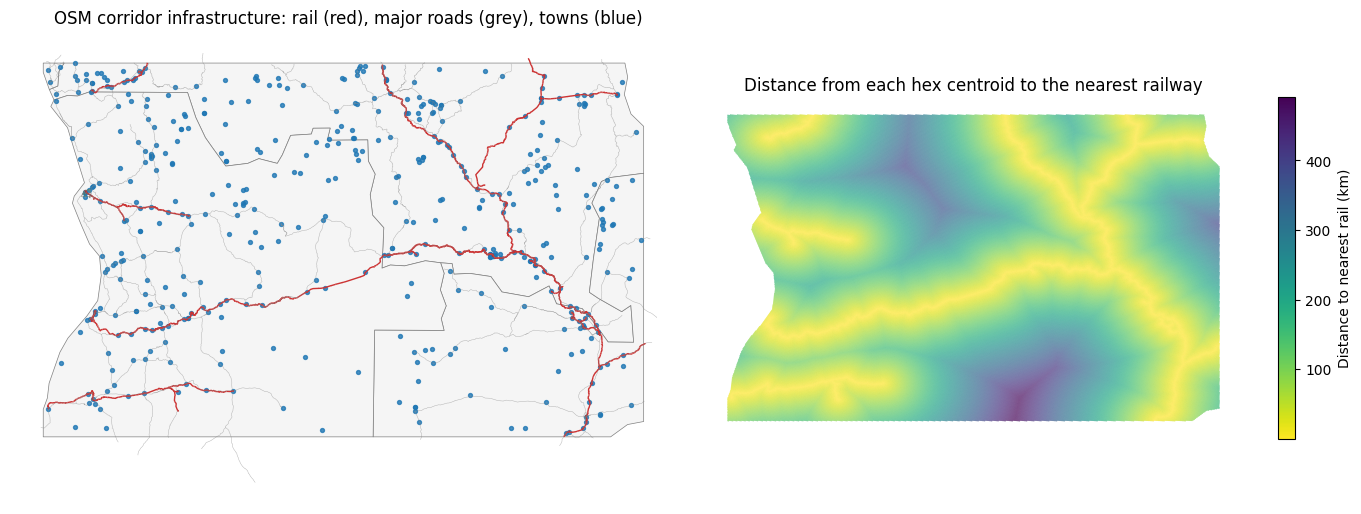

In [12]:
# Figure 2: OSM network map + distance-to-rail surface
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

study_area.to_crs(3857).plot(ax=axes[0], color="#f5f5f5", edgecolor="grey", linewidth=0.5)
rail_lines.to_crs(3857).plot(ax=axes[0], color="#cc3333", linewidth=1.0)
roads_lines.to_crs(3857).plot(ax=axes[0], color="#888888", linewidth=0.35, alpha=0.6)
towns_pts.to_crs(3857).plot(ax=axes[0], color="#1f77b4", markersize=8, alpha=0.8)
axes[0].set_title("OSM corridor infrastructure: rail (red), major roads (grey), towns (blue)")
axes[0].set_axis_off()

for s in [dist_rail, dist_road, dist_town]:
    hex_features = hex_features.drop(columns=[c for c in [s.name] if c in hex_features.columns])
    hex_features = hex_features.merge(s, left_on="hex_id", right_index=True, how="left")

hex_features.to_crs(3857).plot(
    ax=axes[1], column="dist_rail_km", cmap="viridis_r", edgecolor="none",
    legend=True, legend_kwds={"label": "Distance to nearest rail (km)", "shrink": 0.6},
)
axes[1].set_title("Distance from each hex centroid to the nearest railway")
axes[1].set_axis_off()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_infrastructure.png", dpi=150)
plt.show()

Mining-relevant subset: 28,703 hexes


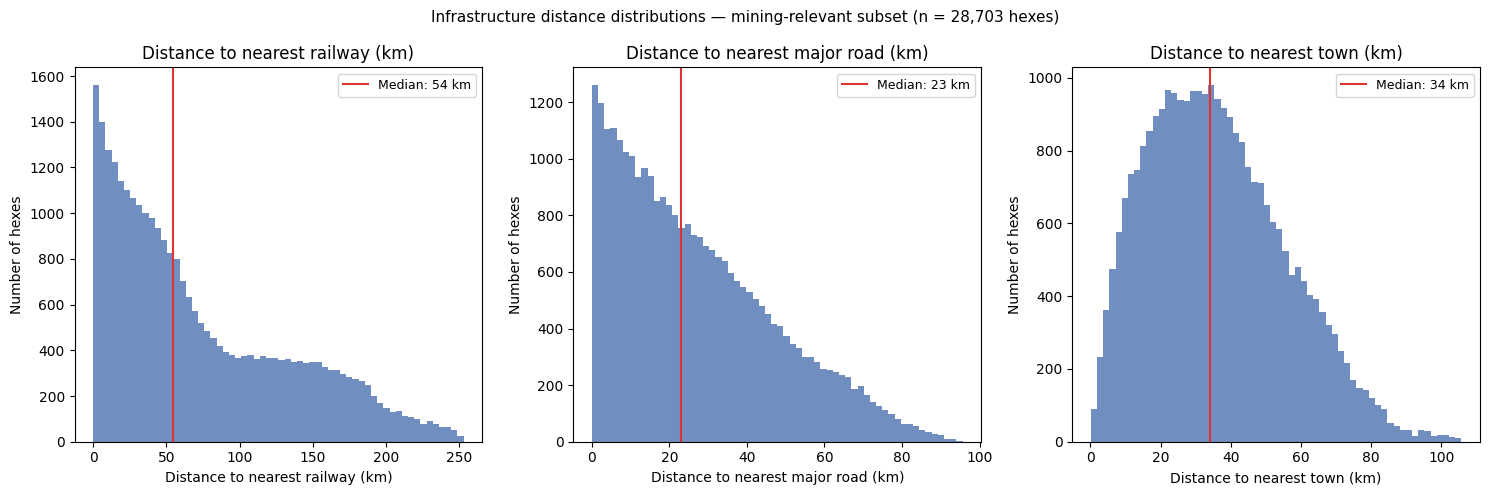

In [13]:
# Figure 3: Infrastructure distance distributions on the mining-relevant subset
RING_RADIUS = 24
concession_hex = set(
    hex_features.loc[
        (hex_features["asm_share"] > 0) | (hex_features["lsm_share"] > 0), "hex_id"
    ]
)
candidate = set()
for hid in concession_hex:
    candidate |= set(h3.grid_disk(hid, RING_RADIUS))
subset = hex_features[hex_features["hex_id"].isin(candidate)].copy()
print(f"Mining-relevant subset: {len(subset):,} hexes")

dist_cols = {
    "dist_rail_km": "Distance to nearest railway (km)",
    "dist_road_km": "Distance to nearest major road (km)",
    "dist_town_km": "Distance to nearest town (km)",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, label) in zip(axes, dist_cols.items()):
    vals = subset[col].dropna()
    med = vals.median()
    ax.hist(vals, bins=60, color="#4c72b0", edgecolor="none", alpha=0.8)
    ax.axvline(med, color="#dd3333", linewidth=1.5, label=f"Median: {med:.0f} km")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of hexes")
    ax.set_title(label)
    ax.legend(fontsize=9)

fig.suptitle(f"Infrastructure distance distributions — mining-relevant subset (n = {len(subset):,} hexes)", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_distance_distributions.png", dpi=150)
plt.show()

## 5. ACLED conflict events

ACLED data were downloaded manually from the Research-tier dashboard (Angola, DRC, Zambia, January 2015 – May 2025). We filter to events with geo-precision codes 1 or 2 (exact or approximate point location) and then apply a two-pronged mining-relevance filter: keyword match in the event notes, or location within 5 km of any Liu or USGS mining polygon.

In [ ]:
CSV_PATH = RAW_DIR / "ACLED Data_2026-05-11.csv"
PRE_START       = pd.Timestamp("2015-01-01")
MINING_BUFFER_M = 5_000

events = pd.read_csv(CSV_PATH)
events["event_date"] = pd.to_datetime(events["event_date"], errors="coerce")

events = events[
    events["country"].isin(["Angola", "Democratic Republic of Congo", "Zambia"])
    & events["geo_precision"].isin([1, 2])
    & events["latitude"].between(LOBITO_BBOX[1], LOBITO_BBOX[3])
    & events["longitude"].between(LOBITO_BBOX[0], LOBITO_BBOX[2])
    & (events["event_date"] >= PRE_START)
].copy()
print(f"Corridor events: {len(events):,}")

In [ ]:
MINING_RE = re.compile(
    r"\b(mine|mining|miner|cobalt|copper|"
    r"tailings?|artisan(?:al)?|"
    r"kolwezi|tenke|fungurume|mutanda|kamoa|"
    r"likasi|lubumbashi|kasumbalesa|"
    r"chingola|kitwe|mufulira|luanshya|ndola|solwezi|"
    r"mopani|kcm|kcc|"
    r"glencore|cmoc|gecamines|chemaf|zccm|"
    r"barrick|first.?quantum|vedanta|sino[- ]hydro|sicomines)\b",
    re.IGNORECASE,
)
events["mining_keyword"] = events["notes"].fillna("").apply(lambda s: bool(MINING_RE.search(s)))
print(f"Keyword matches: {events['mining_keyword'].sum():,}")

mining_union = unary_union(
    [
        unary_union(gpd.read_file(PROCESSED_DIR / "mines_lobito_corridor.gpkg").to_crs(EQUAL_AREA_CRS).make_valid()),
        unary_union(gpd.read_file(PROCESSED_DIR / "mines_usgs_copperbelt.gpkg").to_crs(EQUAL_AREA_CRS).make_valid()),
    ]
)
mining_buffer_gdf = gpd.GeoDataFrame(geometry=[mining_union.buffer(MINING_BUFFER_M)], crs=EQUAL_AREA_CRS)

events_gdf = gpd.GeoDataFrame(
    events,
    geometry=gpd.points_from_xy(events["longitude"], events["latitude"]),
    crs="EPSG:4326",
).to_crs(EQUAL_AREA_CRS)

joined = gpd.sjoin(events_gdf[["event_id_cnty", "geometry"]], mining_buffer_gdf, predicate="intersects", how="left")
near_ids = set(joined.loc[joined["index_right"].notna(), "event_id_cnty"])
events["mining_proximity"] = events["event_id_cnty"].isin(near_ids)
print(f"Within 5 km of mining: {events['mining_proximity'].sum():,}")

overlap = (events["mining_keyword"] & events["mining_proximity"]).sum()
print(f"Overlap (keyword AND proximity): {overlap:,}")

events["is_mining"] = events["mining_keyword"] | events["mining_proximity"]
mining_events = events[events["is_mining"]].copy()
print(f"Mining-related total: {len(mining_events):,} ({len(mining_events)/len(events):.1%} of corridor events)")

In [ ]:
def assign_hex(df):
    return [h3.latlng_to_cell(lat, lon, H3_RES) for lat, lon in zip(df["latitude"], df["longitude"])]

events["hex_id"]        = assign_hex(events)
mining_events["hex_id"] = assign_hex(mining_events)

In [ ]:
agg_total  = events.groupby("hex_id").size().rename("n_inc_total")
agg_mining = mining_events.groupby("hex_id").size().rename("n_inc_mining_total")
fatalities = mining_events.groupby("hex_id")["fatalities"].sum().rename("n_mining_fatalities")

aggregates = (
    pd.concat([agg_total, agg_mining, fatalities], axis=1)
    .fillna(0).astype(int)
)
print(aggregates[["n_inc_total", "n_inc_mining_total", "n_mining_fatalities"]].describe().round(2))

In [18]:
drop_cols = [c for c in aggregates.columns if c in hex_features.columns]
hex_features = hex_features.drop(columns=drop_cols)
hex_features = hex_features.merge(aggregates, left_on="hex_id", right_index=True, how="left")
inc_cols = list(aggregates.columns)
hex_features[inc_cols] = hex_features[inc_cols].fillna(0)
hex_features[[c for c in inc_cols if c.startswith("n_")]] = (
    hex_features[[c for c in inc_cols if c.startswith("n_")]].astype(int)
)

out_path = PROCESSED_DIR / "hex_features.gpkg"
out_path.unlink(missing_ok=True)
hex_features.to_file(out_path, driver="GPKG")
print(f"Wrote {out_path} — {len(hex_features):,} hexes, {hex_features.shape[1]} columns")
print(f"Hexes with any mining incident: {(hex_features['n_inc_mining_total'] > 0).sum():,}")

Wrote /Users/inge/Desktop/ITU/GeoDS/gds/data/processed/hex_features.gpkg — 383,693 hexes, 22 columns
Hexes with any mining incident: 140
